In [94]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from scipy.stats import mannwhitneyu

In [95]:
df = pd.read_csv('source/FReDA4.csv')

In [96]:
mask1 = (
    df.groupby('CoupleId')['Frequency_F']
    .nunique()
    .eq(1)
)

mask2 = (
    df.groupby('CoupleId')['Desire_F']
    .nunique()
    .eq(1)
)

df['Match_Frequency'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask1.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask1.get(cid, False) else 0
)
df['Match_Frequency_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask1.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask1.get(cid, False) else 0
)

df['Match_Desire'] = df['CoupleId'].map(
    lambda cid: 'Aligned' if mask2.get(cid, False) else 'Misaligned'
    # lambda cid: 1 if mask2.get(cid, False) else 0
)

df['Match_Desire_n'] = df['CoupleId'].map(
    # lambda cid: 'Alignment' if mask2.get(cid, False) else 'Disalignment'
    lambda cid: 1 if mask2.get(cid, False) else 0
)

In [97]:
data = df.copy()

In [98]:
df["Group1"].value_counts()

Group1
SubGroup-Satisfied               3842
SubGroup-DeprivedBoth            3402
SubGroup-DeprivedPartner         2856
SubGroup-DeprivedMe              2084
SubGroup-Mixed                    660
SubGroup-OversaturatedPartner     382
SubGroup-OversaturatedMe          284
SubGroup-OversaturatedBoth         90
Name: count, dtype: int64

In [99]:
df["Group2"].value_counts()

Group2
One-sided Deprivation       4940
Couple Satisfaction         3842
Couple Deprivation          3402
One-sided Oversaturation     666
Couple Dissatisfaction       660
Couple Oversaturation         90
Name: count, dtype: int64

In [100]:
df["Group3"].value_counts()

Group3
Couple Deprivation       8342
Couple Satisfaction      3842
Couple Oversaturation     756
Couple Mixed              660
Name: count, dtype: int64

In [101]:
satisfied = df[df["Group3"] == "Couple Satisfaction"].copy()
mixed = df[df["Group3"] == "Couple Mixed"].copy()
deprived = df[df["Group3"] == "Couple Deprivation"].copy()
saturated = df[df["Group3"] == "Couple Oversaturation"].copy()

In [102]:
def collapse_kde_into_bins(kde_df, bins=[0, 1, 2, 3, 4, 5, 6]):
    df = kde_df.copy()
    N = df["N_total"].iloc[0]

    dx = df["x"].diff().median()

    df["bin"] = pd.cut(df["x"], bins=bins, labels=range(len(bins) - 1), right=False)

    out = (
        df.groupby("bin")
        .apply(lambda g: pd.Series({
            "density_sum": (g["density"] * dx).sum(),
        }))
        .reset_index()
    )
    return out

In [103]:
group_sizes = {
    "Satisfied": satisfied.shape[0],
    "Deprived": deprived.shape[0],
    "Oversaturated": saturated.shape[0],
    "Mixed": mixed.shape[0]
}

ref_group = "Deprived"
ref_size = group_sizes[ref_group]

y_limits = {}

alpha = 0.25   # softness parameter (try 0.4–0.6)

for group, size in group_sizes.items():
    scale = (ref_size / size) ** alpha
    height = 1 * scale          # base height = 1
    y_limits[group] = [-height/2, height/2]

y_limits["Deprived"] = [-0.52, 0.52]

In [104]:
bw = 1.15
new_palette = [
    "#C4A000",
    "#355C9C",
    "#B76A8D",
    "#009688",
]

ft_size = 18
tt_size = 24
x_title = 0.01
y_title = 0.89

shade = [0.25, 0.50, 0.75, 0.95]
shade.reverse()
inside = ["quartile", None, None, None]

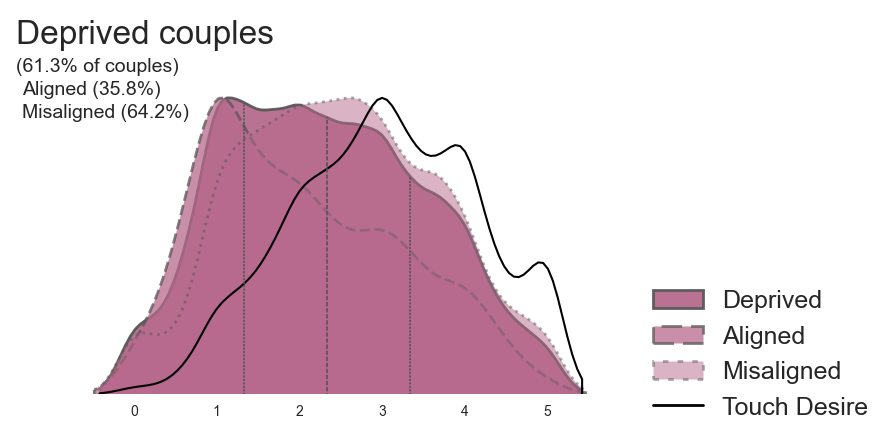

In [105]:
color = new_palette[2]

conditions = {
    "Deprived": data[data["Group3"] == "Couple Deprivation"],
    "Aligned": data[(data["Group3"] == "Couple Deprivation") & (data["Match_Frequency_n"] == 1)],
    "Misaligned": data[(data["Group3"] == "Couple Deprivation") & (data["Match_Frequency_n"] == 0)]
}

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, subset) in enumerate(conditions.items()):
    n_before = len(ax.collections)
    ax = sns.violinplot(
        data=subset,
        x='Frequency',
        color=color,
        label=label,
        alpha=shade[i],
        inner=inside[i],
        dodge=False,
        saturation=1,
    )
    new_violins = ax.collections[n_before:]

    for violin in new_violins:
        if i == 0:
            violin.set_linestyle("-")  # solid
            violin.set_linewidth(2)
        elif i == 1:
            violin.set_linestyle("--")  # dashdot
            violin.set_linewidth(2)
        elif i == 2:
            violin.set_linestyle(":")  # dotted
            violin.set_linewidth(2)

for line in ax.lines:
    line.set_label("_nolegend_")

sns.violinplot(data=deprived,
               x="Desire",
               bw_adjust=bw,
               fill=False,
               color="k",
               inner=None,
               )

plt.grid(False)

handles, labels = ax.get_legend_handles_labels()
desire_handle = Line2D([0], [0], color='k', lw=2, linestyle='-')
handles.append(desire_handle)

labels2 = [
    "Deprived",
    "Aligned",
    "Misaligned",
    "Touch Desire"
]

x_legend = plt.legend(
    handles=handles,
    labels=labels2,
    bbox_to_anchor=(1, 0.33),
    fontsize=ft_size,
    fancybox=False,
    frameon=False,
)

l = plt.ylabel('')
n = plt.xlabel('')

current_xlim = ax.get_xlim()
ax.set_xlim(left=-1.5, right=6)
ax.set_xticks([0, 1, 2, 3, 4, 5])

sns.despine(top=True, right=True, left=True, bottom=True)

y_limits["Deprived"][0] = 0
ax.set_ylim(y_limits["Deprived"])

t1 = plt.title("Deprived couples", fontsize=tt_size, y=y_title, x=x_title, ha='left')

title_x, title_y = t1.get_position()
y_text = title_y - 0.05

deprived_data = data[data["Group3"] == "Couple Deprivation"]
total_deprived = len(deprived_data)
aligned_pct = (len(deprived_data[deprived_data["Match_Frequency_n"] == 1]) / total_deprived) * 100
misaligned_pct = (len(deprived_data[deprived_data["Match_Frequency_n"] == 0]) / total_deprived) * 100

t2 = plt.text(x=0.01, y=y_text, s='(61.3% of couples)', fontsize=14, alpha=1, transform=ax.transAxes)
t3 = plt.text(x=0.02, y=y_text - 0.06, s=f'Aligned ({aligned_pct:.1f}%)', fontsize=14, alpha=1, transform=ax.transAxes)
t4 = plt.text(x=0.02, y=y_text - 2 * 0.06, s=f'Misaligned ({misaligned_pct:.1f}%)', fontsize=14, alpha=1,
              transform=ax.transAxes)
plt.savefig('output/img/kde/Deprivation7.png', dpi=600, transparent=False, bbox_inches='tight')

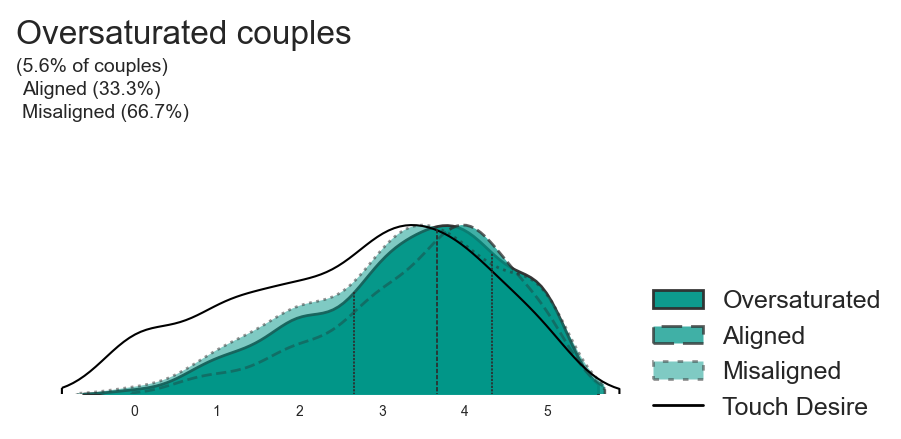

In [106]:
color = new_palette[3]

conditions = {
    "Oversaturated": data[data["Group3"] == "Couple Oversaturation"],
    "Aligned": data[(data["Group3"] == "Couple Oversaturation") & (data["Match_Frequency_n"] == 1)],
    "Misaligned": data[(data["Group3"] == "Couple Oversaturation") & (data["Match_Frequency_n"] == 0)]
}

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, subset) in enumerate(conditions.items()):
    n_before = len(ax.collections)
    ax = sns.violinplot(
        data=subset,
        x='Frequency',
        color=color,
        label=label,
        alpha=shade[i],
        inner=inside[i],
        dodge=False,
        saturation=1,
    )
    new_violins = ax.collections[n_before:]

    for violin in new_violins:
        if i == 0:
            violin.set_linestyle("-")  # solid
            violin.set_linewidth(2)
        elif i == 1:
            violin.set_linestyle("--")  # dashdot
            violin.set_linewidth(2)
        elif i == 2:
            violin.set_linestyle(":")  # dotted
            violin.set_linewidth(2)

for line in ax.lines:
    line.set_label("_nolegend_")

sns.violinplot(data=saturated,
               x="Desire",
               bw_adjust=bw,
               fill=False,
               color="k",
               inner=None,
               )

plt.grid(False)

handles, labels = ax.get_legend_handles_labels()
desire_handle = Line2D([0], [0], color='k', lw=2, linestyle='-')
handles.append(desire_handle)

labels2 = [
    "Oversaturated",
    "Aligned",
    "Misaligned",
    "Touch Desire"
]

x_legend = plt.legend(
    handles=handles,
    labels=labels2,
    bbox_to_anchor=(1, 0.33),
    fontsize=ft_size,
    fancybox=False,
    frameon=False,
)

l = plt.ylabel('')
n = plt.xlabel('')

current_xlim = ax.get_xlim()
ax.set_xlim(left=-1.5, right=6)
ax.set_xticks([0, 1, 2, 3, 4, 5])

sns.despine(top=True, right=True, left=True, bottom=True)

y_limits["Oversaturated"][0] = 0
ax.set_ylim(y_limits["Oversaturated"])

t1 = plt.title("Oversaturated couples", fontsize=tt_size, y=y_title, x=x_title, ha='left')

title_x, title_y = t1.get_position()
y_text = title_y - 0.05

data1 = data[data["Group3"] == "Couple Oversaturation"]
data2 = len(data1)
aligned_pct = (len(data1[data1["Match_Frequency_n"] == 1]) / data2) * 100
misaligned_pct = (len(data1[data1["Match_Frequency_n"] == 0]) / data2) * 100

t2 = plt.text(x=0.01, y=y_text, s='(5.6% of couples)', fontsize=14, alpha=1, transform=ax.transAxes)
t3 = plt.text(x=0.02, y=y_text - 0.06, s=f'Aligned ({aligned_pct:.1f}%)', fontsize=14, alpha=1, transform=ax.transAxes)
t4 = plt.text(x=0.02, y=y_text - 2 * 0.06, s=f'Misaligned ({misaligned_pct:.1f}%)', fontsize=14, alpha=1,
              transform=ax.transAxes)

plt.savefig('output/img/kde/Oversaturation7.png', dpi=600, transparent=False, bbox_inches='tight')

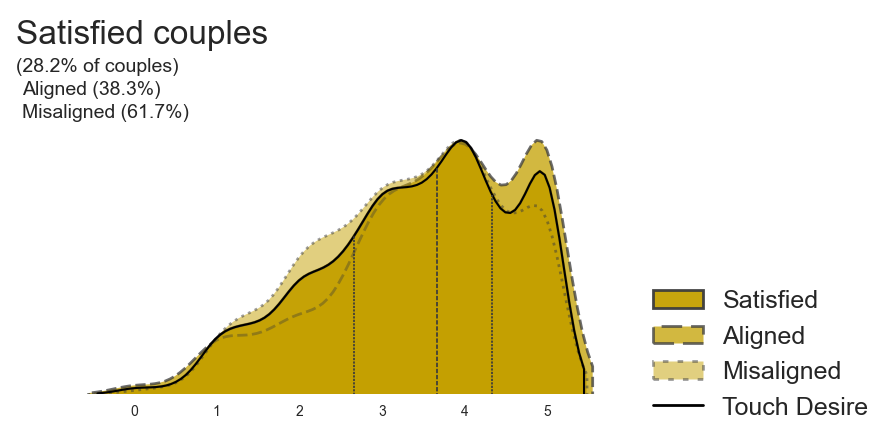

In [107]:
color = new_palette[0]
conditions = {
    "Satisfaction": data[data["Group3"] == "Couple Satisfaction"],
    "Aligned": data[(data["Group3"] == "Couple Satisfaction") & (data["Match_Frequency_n"] == 1)],
    "Misaligned": data[(data["Group3"] == "Couple Satisfaction") & (data["Match_Frequency_n"] == 0)]
}

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, subset) in enumerate(conditions.items()):
    n_before = len(ax.collections)

    ax = sns.violinplot(
        data=subset,
        x='Frequency',
        color=color,
        label=label,
        alpha=shade[i],
        inner=inside[i],
        dodge=False,
        saturation=1,
    )
    new_violins = ax.collections[n_before:]

    for violin in new_violins:
        if i == 0:
            violin.set_linestyle("-") # solid
            violin.set_linewidth(2)
        elif i == 1:
            violin.set_linestyle("--") # dashdot
            violin.set_linewidth(2)
        elif i == 2:
            violin.set_linestyle(":") # dotted
            violin.set_linewidth(2)

for line in ax.lines:
    line.set_label("_nolegend_")

sns.violinplot(data=satisfied,
            x="Desire",
            fill=False,
            color="k",
            inner = None
            )
plt.grid(False)

handles, labels = ax.get_legend_handles_labels()
desire_handle = Line2D([0], [0], color='k', lw=2, linestyle='-')
handles.append(desire_handle)

labels2 = [
    "Satisfied",
    "Aligned",
    "Misaligned",
    "Touch Desire"
]

x_legend = plt.legend(
    handles=handles,
    labels=labels2,
    bbox_to_anchor=(1, 0.33),
    fontsize=ft_size,
    fancybox=False,
    frameon=False,
)

l = plt.ylabel('')
n = plt.xlabel('')

current_xlim = ax.get_xlim()
ax.set_xlim(left=-1.5, right=6)
ax.set_xticks([0, 1, 2, 3, 4, 5])

sns.despine(top=True, right=True, left=True, bottom=True)

y_limits["Satisfied"][0] = 0
ax.set_ylim(y_limits["Satisfied"])


t1 = plt.title("Satisfied couples", fontsize=tt_size, y=y_title, x=x_title, ha='left')
title_x, title_y = t1.get_position()
y_text = title_y - 0.05

data1 = data[data["Group3"] == "Couple Satisfaction"]
data2 = len(data1)
aligned_pct = (len(data1[data1["Match_Frequency_n"] == 1]) / data2) * 100
misaligned_pct = (len(data1[data1["Match_Frequency_n"] == 0]) / data2) * 100

t2 = plt.text(x=0.01, y=y_text, s='(28.2% of couples)', fontsize=14, alpha=1, transform=ax.transAxes)
t3 = plt.text(x=0.02, y=y_text - 0.06, s=f'Aligned ({aligned_pct:.1f}%)', fontsize=14, alpha=1, transform=ax.transAxes)
t4 = plt.text(x=0.02, y=y_text - 2 * 0.06, s=f'Misaligned ({misaligned_pct:.1f}%)', fontsize=14, alpha=1,
              transform=ax.transAxes)

plt.savefig('output/img/kde/Satisfaction7.png', dpi=600, transparent=False, bbox_inches='tight')

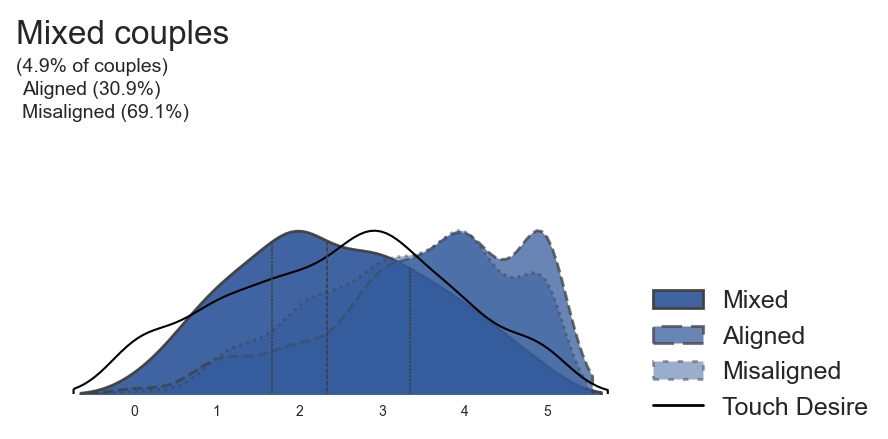

In [108]:
color = new_palette[1]

conditions = {
    "Mixed": data[data["Group3"] == "Couple Mixed"],
    "Aligned": data[(data["Group3"] == "Couple Satisfaction") & (data["Match_Frequency_n"] == 1)],
    "Misaligned": data[(data["Group3"] == "Couple Satisfaction") & (data["Match_Frequency_n"] == 0)]
}

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, subset) in enumerate(conditions.items()):
    n_before = len(ax.collections)

    ax = sns.violinplot(
        data=subset,
        x='Frequency',
        color=color,
        label=label,
        alpha=shade[i],
        inner=inside[i],
        dodge=False,
        saturation=1,
    )
    new_violins = ax.collections[n_before:]

    for violin in new_violins:
        if i == 0:
            violin.set_linestyle("-") # solid
            violin.set_linewidth(2)
        elif i == 1:
            violin.set_linestyle("--") # dashdot
            violin.set_linewidth(2)
        elif i == 2:
            violin.set_linestyle(":") # dotted
            violin.set_linewidth(2)

for line in ax.lines:
    line.set_label("_nolegend_")

sns.violinplot(data=mixed,
            x="Desire",
            fill=False,
            color="k",
            inner = None
            )
plt.grid(False)

handles, labels = ax.get_legend_handles_labels()
desire_handle = Line2D([0], [0], color='k', lw=2, linestyle='-')
handles.append(desire_handle)

labels2 = [
    "Mixed",
    "Aligned",
    "Misaligned",
    "Touch Desire"
]

x_legend = plt.legend(
    handles=handles,
    labels=labels2,
    bbox_to_anchor=(1, 0.33),
    fontsize=ft_size,
    fancybox=False,
    frameon=False,
)

l = plt.ylabel('')
n = plt.xlabel('')

current_xlim = ax.get_xlim()
ax.set_xlim(left=-1.5, right=6)
ax.set_xticks([0, 1, 2, 3, 4, 5])

sns.despine(top=True, right=True, left=True, bottom=True)

y_limits["Mixed"][0] = 0
ax.set_ylim(y_limits["Mixed"])


t1 = plt.title("Mixed couples", fontsize=tt_size, y=y_title, x=x_title, ha='left')
title_x, title_y = t1.get_position()
y_text = title_y - 0.05

data1 = data[data["Group3"] == "Couple Mixed"]
data2 = len(data1)
aligned_pct = (len(data1[data1["Match_Frequency_n"] == 1]) / data2) * 100
misaligned_pct = (len(data1[data1["Match_Frequency_n"] == 0]) / data2) * 100

t2 = plt.text(x=0.01, y=y_text, s='(4.9% of couples)', fontsize=14, alpha=1, transform=ax.transAxes)
t3 = plt.text(x=0.02, y=y_text - 0.06, s=f'Aligned ({aligned_pct:.1f}%)', fontsize=14, alpha=1, transform=ax.transAxes)
t4 = plt.text(x=0.02, y=y_text - 2 * 0.06, s=f'Misaligned ({misaligned_pct:.1f}%)', fontsize=14, alpha=1,
              transform=ax.transAxes)
plt.savefig('output/img/kde/Mixed7.png', dpi=600, transparent=False, bbox_inches='tight')